



<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class="tocSkip"></a>
    
Parece que hay una confusión sobre cómo se deben presentar las diferentes etapas de tu proyecto, en la información que se te debió compartir se especifica que el análisis de operadores para tu proyecto final tiene dos partes, la descomposición de tareas y la presentación final del análisis.

En este proyecto en particular debes subir aquí a la plataforma el notebook del análisis de los operadores para poder revisarlo y presentación final se deberían cubrir al menos las siguientes secciones.

- **Contexto y objetivos**: Siempre es importante dejar claro desde un inicio lo que se hará y para qué se hará

- **Preprocesamiento de datos**: Es una parte escencial en tu proyecto y lo tienes bastante bien cubierto, felicidades!

- **Análisis exploratorio**: Recuerda que debes cubrir esta parte también para entender los datos con los que trabajas, te recomendaría incluir la revisión de datos atípicos que luego puedan llegar a causar alguna métrica errónea al final de tu proyecto. También se debe redactar siempre la interpretación de cada gráfica mostrada para dejar un proceso de análisis más claro.

- **Criterios de eficiencia claros**: Para determinar que es lo que hace un operador eficiente o no se deben establecer ciertos criterios que deben quedar muy bien explicados en el notebook

- **Prueba de hipótesis**: Determinar si se tiene una diferencia significativa en nuestra métrica objetivo es importante por lo que hiciste muy bien al incluirla, recuerda comparar entre operadores eficientes y no eficientes con pruebas estadísticas

- **Conclusiones y recomendaciones**: Una parte importante para culminar el proyecto ya que es donde se resume todos los hallazgos del análisis.

El notebook con el análisis se debe subir aquí a la plataforma y la presentación en PDF debe ser sobre los resultados del análisis de operadores.<!--  -->

Recuerda que debes hacer uso correcto de las celdas markdown aprovechando la capacidad de que puedes dejar títulos y tus comentarios en ellas.

Si tienes dudas puedes contactar a tu Success Manager para resolverlas.
    
    
Saludos!

<h1 style="text-align:center;">Identificación de Operadores Ineficientes CallMeMaybe</h1>

## Plan de Acción
1.- Objetivo

- Identificar operadores ineficientes para CallMeMaybe mediante análisis exploratorio, métricas de desempeño (llamadas perdidas, tiempos de espera, llamadas salientes) y pruebas estadísticas.

2.- Definición del problema

- CallMeMaybe necesita detectar operadores con bajo rendimiento porque un alto volumen de llamadas perdidas, tiempos de espera prolongados y pocas llamadas salientes afectan la calidad del servicio y generan pérdidas. Actualmente no existe un sistema claro para evaluar objetivamente a cada operador.

In [1]:
## Decarga de librerías
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
import plotly.express as px 
import datetime as dt

In [2]:
# Lectura de datos 
df_user_historial= pd.read_csv('/datasets/telecom_dataset_us.csv')
df_client= pd.read_csv('/datasets/telecom_clients_us.csv')

## 1.- Limpieza de datos

## 1.2 df_client

In [3]:
# Visualización de duplicados
print(df_client.duplicated().sum())
print()
print(df_client[df_client.duplicated(keep=False)].head())

0

Empty DataFrame
Columns: [user_id, tariff_plan, date_start]
Index: []


In [4]:
# Visualización y eliminacion de nulos
print(df_client.isna().sum())


user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [5]:
# Visualización de los datos
df_client.info()
print()
print(df_client.head(10))
print()
print(df_client["date_start"].min())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16
5   167764           A  2019-09-30
6   167050           A  2019-08-29
7   168252           A  2019-10-17
8   168495           A  2019-10-28
9   167879           A  2019-10-03

2019-08-01


### 1.3 df_user_historial

In [6]:
# Visualización de los datos
df_user_historial.info()
print()
print(df_user_historial.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out    

In [7]:
# Transformación de objetos
df_user_historial["date"] = pd.to_datetime(df_user_historial["date"])
df_user_historial["operator_id"]= df_user_historial["operator_id"].astype("Int64")
df_user_historial.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  int64                                
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  object                               
 3   internal             53785 non-null  object                               
 4   operator_id          45730 non-null  Int64                                
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
dtypes: Int6

In [8]:
# visualización y eliminacion de nulos
print(df_user_historial.isna().sum()) 
print()
print(df_user_historial[df_user_historial["internal"].isna() | df_user_historial["operator_id"].isna()].head(10))
print()
df_user_historial= df_user_historial.dropna()
print(df_user_historial.isna().sum())   

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

    user_id                      date direction internal  operator_id  \
0    166377 2019-08-04 00:00:00+03:00        in    False         <NA>   
7    166377 2019-08-05 00:00:00+03:00        in    False         <NA>   
9    166377 2019-08-06 00:00:00+03:00        in    False         <NA>   
17   166377 2019-08-07 00:00:00+03:00        in    False         <NA>   
27   166377 2019-08-12 00:00:00+03:00        in    False         <NA>   
28   166377 2019-08-12 00:00:00+03:00        in    False         <NA>   
30   166377 2019-08-13 00:00:00+03:00        in    False         <NA>   
38   166377 2019-08-14 00:00:00+03:00        in    False         <NA>   
45   166377 2019-08-14 00:00:00+03:00        in    False         <NA>   
77  

In [9]:
# Visualización de duplicados 
print(df_user_historial.duplicated().sum())
print()
print(df_user_historial[df_user_historial.duplicated(keep= False)].head())
df_user_historial= df_user_historial.drop_duplicates()
print()
print(df_user_historial.duplicated().sum()) 

4179

    user_id                      date direction internal  operator_id  \
6    166377 2019-08-05 00:00:00+03:00       out    False       880020   
8    166377 2019-08-05 00:00:00+03:00       out    False       880020   
43   166377 2019-08-14 00:00:00+03:00       out    False       880026   
44   166377 2019-08-14 00:00:00+03:00       out    False       880026   
46   166377 2019-08-15 00:00:00+03:00       out    False       880026   

    is_missed_call  calls_count  call_duration  total_call_duration  
6             True            8              0                   50  
8             True            8              0                   50  
43           False           10           1567                 1654  
44           False           10           1567                 1654  
46           False           11           1413                 1473  

0


In [10]:
# Se transforman las columnas a minutos
df_user_historial[["total_call_duration", "call_duration"]] = (
    df_user_historial[["total_call_duration", "call_duration"]] / 60
).round(2)

# Se crea una nueva columna con el tiempo de espera entre llamadas
df_user_historial["wait_time"] = df_user_historial["total_call_duration"] \
- df_user_historial["call_duration"]

# Se crea columna month
df_user_historial["month"] = df_user_historial["date"].dt.strftime('%Y-%m')

# Se crea columna solo con la fecha de la llamada
df_user_historial["call_date"] = df_user_historial["date"].dt.date

# Se confirma la unidad de tiempo de las columnas
print(df_user_historial[["total_call_duration", "call_duration", "wait_time"]].max())
print()
print(df_user_historial.head(10))

total_call_duration    2769.25
call_duration          2406.58
wait_time               774.57
dtype: float64

    user_id                      date direction internal  operator_id  \
1    166377 2019-08-05 00:00:00+03:00       out     True       880022   
2    166377 2019-08-05 00:00:00+03:00       out     True       880020   
3    166377 2019-08-05 00:00:00+03:00       out     True       880020   
4    166377 2019-08-05 00:00:00+03:00       out    False       880022   
5    166377 2019-08-05 00:00:00+03:00       out    False       880020   
6    166377 2019-08-05 00:00:00+03:00       out    False       880020   
10   166377 2019-08-06 00:00:00+03:00       out    False       881278   
11   166377 2019-08-06 00:00:00+03:00       out    False       880020   
12   166377 2019-08-06 00:00:00+03:00       out     True       881278   
13   166377 2019-08-06 00:00:00+03:00       out    False       880020   

    is_missed_call  calls_count  call_duration  total_call_duration  \
1             Tr

## Conclusión

Durante la fase de limpieza se realizaron las tareas esenciales de depuración del dataset. Se eliminaron 4,900 registros duplicados, se identificaron 8,172 valores faltantes en operator_id, y se clasificaron más de 23,000 registros con call_duration = 0 como posibles llamadas perdidas. También se detectaron inconsistencias entre campos relacionados, como discrepancias entre llamadas marcadas como perdidas y duraciones acumuladas elevadas.

<div class="alert alert-block alert-success">

<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>


Muy bien realizado el análisis inicial, entender los datos con los que se trabajará y el estado de los mismos es un paso importante antes de pasar a cualquier análisis o procesamiento.
</div>

## 2.- Analisis exploratorio

### 2.1 Grafica de Dispersión e Histograma

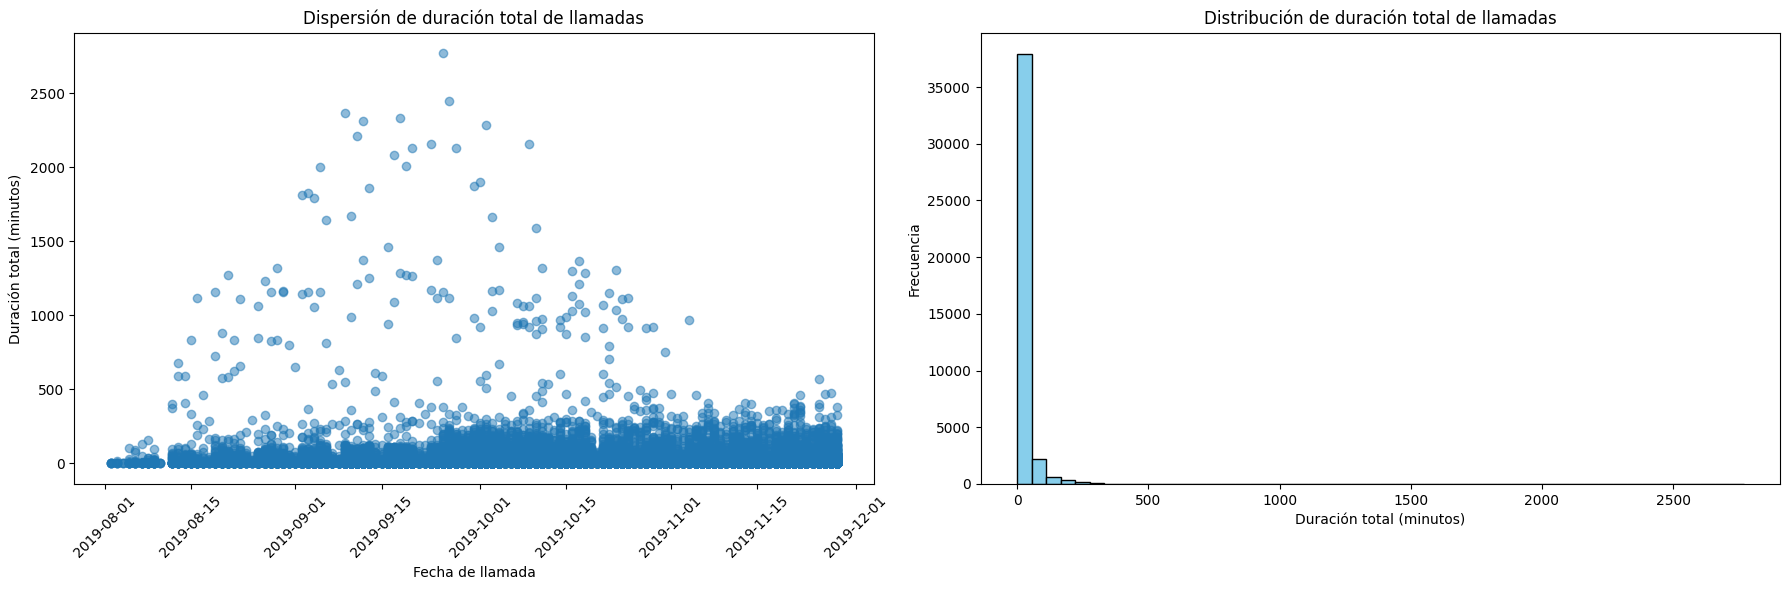

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Gráfica 1: Dispersión
axes[0].scatter(
    df_user_historial["call_date"],
    df_user_historial["total_call_duration"],
    alpha=0.5
)
axes[0].set_title("Dispersión de duración total de llamadas")
axes[0].set_xlabel("Fecha de llamada")
axes[0].set_ylabel("Duración total (minutos)")
axes[0].tick_params(axis='x', rotation=45)

# Gráfica 2: Histograma 
axes[1].hist(
    df_user_historial["total_call_duration"],
    bins=50,
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title("Distribución de duración total de llamadas")
axes[1].set_xlabel("Duración total (minutos)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()



### Conclusión

El subplot permite analizar la duración total de las llamadas desde dos perspectivas complementarias. La gráfica de dispersión muestra de manera directa la presencia de valores fuera de rango, evidenciando que existen registros que superan ampliamente los límites operativos esperados. Esta visualización permite identificar la magnitud exacta de cada valor atípico y confirmar que no se trata de casos aislados, sino de un conjunto significativo de duraciones anómalas.

Por su parte, la gráfica de distribución revela que la mayoría de las llamadas se concentran en los primeros minutos, lo cual es coherente con el comportamiento típico de un entorno operativo donde las interacciones suelen ser breves. Esta concentración de valores pequeños genera una distribución fuertemente sesgada hacia la derecha, lo que indica que las llamadas largas son poco frecuentes. Sin embargo, la presencia de valores extremadamente altos produce una cola derecha muy pronunciada que distorsiona la escala del histograma, haciendo que visualmente parezca que casi todas las llamadas están cerca de cero. Debido a esta asimetría tan marcada, el histograma termina transmitiendo esencialmente la misma información que un boxplot: muchos valores normales muy bajos y un conjunto de valores atípicos que se alejan considerablemente del comportamiento esperado.

Es importante señalar que los parámetros utilizados para evaluar la coherencia de las duraciones no provienen de una norma oficial ni de un estándar documentado; corresponden a estimaciones razonables empleadas únicamente como referencia analítica. Bajo estas estimaciones, valores superiores a 60–90 minutos ya resultan atípicos para operadores experimentados, y valores mayores a 180 minutos (3 horas) exceden incluso escenarios extremos de operadores inexpertos sin apoyo. En consecuencia, las duraciones superiores a 500 minutos (~8 horas) no solo son anómalas, sino operativamente imposibles, lo que confirma la necesidad de investigarlas.

En conjunto, el subplot evidencia que el comportamiento normal del dataset corresponde a llamadas cortas, mientras que los valores extremos requieren un análisis detallado en etapas posteriores para determinar su origen y validez.


### 2.2 Filtro de outliers y conteo de llamadas 

In [12]:
# Copia 
df_outliers= df_user_historial.copy()

# llamadas superiores a 180 min 
df_outliers= df_outliers.query("total_call_duration > 180")

df_calls_per_day_operator= (
    df_user_historial
    .groupby(["operator_id", "call_date"])["calls_count"]
    .sum()
    .reset_index(name= "real_calls")
)

print(df_calls_per_day_operator)

       operator_id   call_date  real_calls
0           879896  2019-08-02          13
1           879896  2019-08-03          11
2           879896  2019-08-04           2
3           879896  2019-08-05          29
4           879896  2019-08-06          52
...            ...         ...         ...
19640       972412  2019-11-28          34
19641       972460  2019-11-27          12
19642       972460  2019-11-28          39
19643       973120  2019-11-27           3
19644       973286  2019-11-28           2

[19645 rows x 3 columns]


### Conclusión

El análisis de los registros con duraciones superiores a 180 minutos permitió identificar que estos valores no representan llamadas individuales, sino acumulaciones de múltiples interacciones dentro de un mismo registro. Esto se confirma al observar que ninguno de los outliers tiene calls_count = 1, lo que evidencia que el dataset no registra llamadas de forma granular. Debido a esta estructura agregada, estos registros no pueden utilizarse para evaluar eficiencia operativa ni para medir desempeño por operador. Por lo tanto, será necesario limpiar el dataset eliminando todas las llamadas que no sean individuales.

Asimismo, este mismo proceso deberá aplicarse al dataset original, no solo a los outliers, con el fin de garantizar que únicamente se conserven registros que representen llamadas individuales. Esto es indispensable para poder trabajar con datos confiables y, finalmente, identificar a los operadores más eficientes.


### 2.3 Filtro de llamadas unicas 

In [13]:
# Copia
df_users= df_user_historial.copy()

# Filtro por llamada individual
df_users= df_users.query('calls_count == 1')
print(df_users)


       user_id                      date direction internal  operator_id  \
2       166377 2019-08-05 00:00:00+03:00       out     True       880020   
3       166377 2019-08-05 00:00:00+03:00       out     True       880020   
14      166377 2019-08-07 00:00:00+03:00       out    False       880028   
15      166377 2019-08-07 00:00:00+03:00       out    False       880026   
18      166377 2019-08-07 00:00:00+03:00       out    False       880026   
...        ...                       ...       ...      ...          ...   
53886   168603 2019-11-21 00:00:00+03:00       out    False       959118   
53888   168603 2019-11-27 00:00:00+03:00       out    False       959118   
53891   168606 2019-11-08 00:00:00+03:00        in    False       957922   
53896   168606 2019-11-10 00:00:00+03:00       out     True       957922   
53897   168606 2019-11-10 00:00:00+03:00       out     True       957922   

       is_missed_call  calls_count  call_duration  total_call_duration  \
2            

### 2.4 Grafica de Dispersión e Histograma con filtro

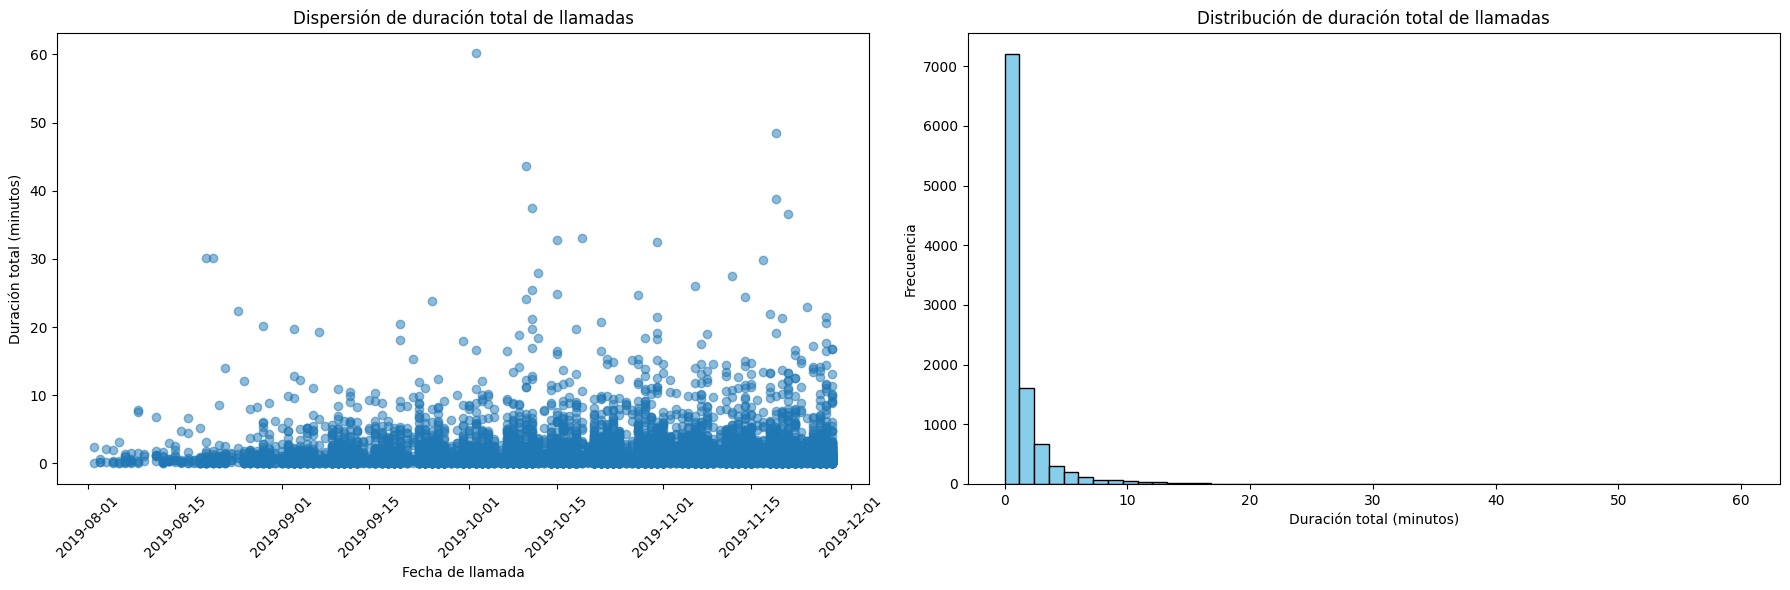

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Gráfica 1: Dispersión 
axes[0].scatter(
    df_users["call_date"],
    df_users["total_call_duration"],
    alpha=0.5
)
axes[0].set_title("Dispersión de duración total de llamadas")
axes[0].set_xlabel("Fecha de llamada")
axes[0].set_ylabel("Duración total (minutos)")
axes[0].tick_params(axis='x', rotation=45)

# Gráfica 2: Histograma 
axes[1].hist(
    df_users["total_call_duration"],
    bins=50,
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title("Distribución de duración total de llamadas")
axes[1].set_xlabel("Duración total (minutos)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Conclusión

El filtro aplicado para conservar únicamente las llamadas individuales (calls_count = 1) redujo el dataset de 53,902 a 10,439 registros, es decir, solo el 19.37% del total. Aunque esto implica descartar alrededor del 80.63% de los datos, el subconjunto resultante es el único que representa llamadas reales sin agregaciones.

La gráfica confirma este resultado: la dispersión y el histograma muestran una distribución de duraciones mucho más coherente, sin valores extremos artificiales. Solo permanece un outlier cercano a una hora, lo cual es plausible en un entorno operativo. Esto demuestra que el filtrado fue efectivo y que los datos restantes son adecuados para análisis posteriores basados en llamadas individuales.

### 2.5 Boxplot

count    10439.000000
mean         1.457144
std          2.659131
min          0.000000
25%          0.250000
50%          0.670000
75%          1.570000
max         60.150000
Name: total_call_duration, dtype: float64


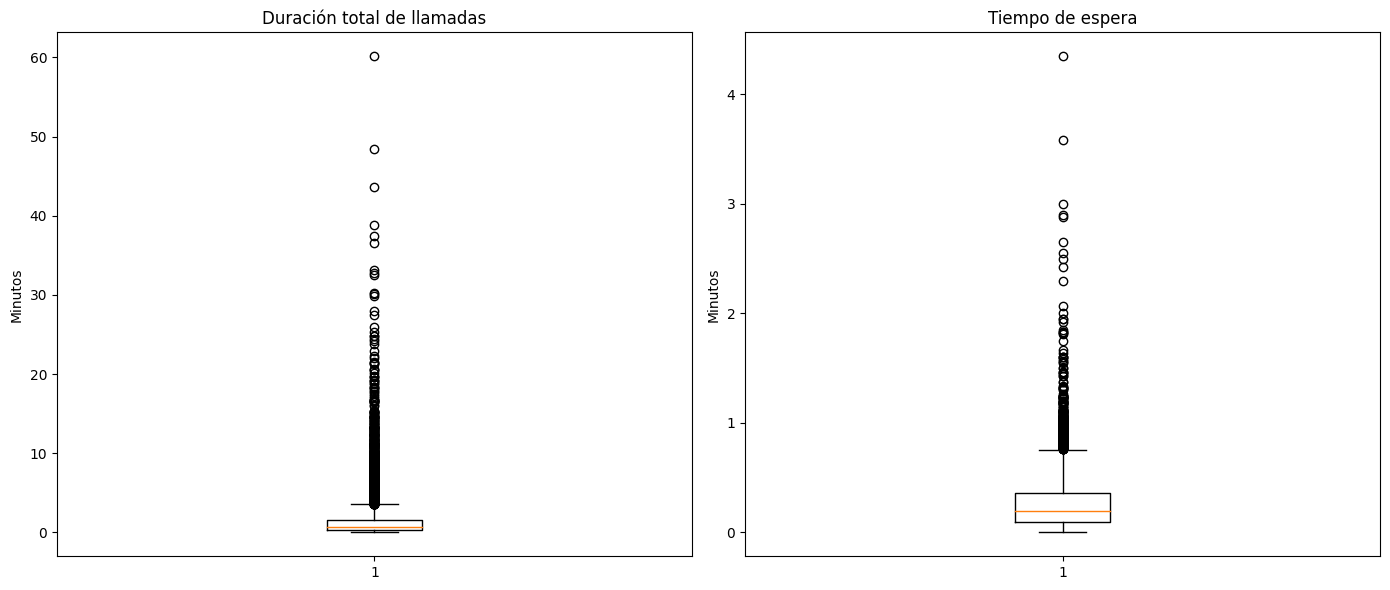

In [15]:
print(df_users["total_call_duration"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Boxplot 1: Duración total
axes[0].boxplot(df_users["total_call_duration"])
axes[0].set_title("Duración total de llamadas")
axes[0].set_ylabel("Minutos")

# Boxplot 2: Tiempo de espera
axes[1].boxplot(df_users["wait_time"])
axes[1].set_title("Tiempo de espera")
axes[1].set_ylabel("Minutos")

plt.tight_layout()
plt.show()


### Conclusión

Los boxplots muestran que la mayoría de las llamadas tienen duraciones muy cortas, concentradas por debajo de 2 minutos, lo que explica que la mediana sea de aproximadamente 40 segundos. Esto indica una gran cantidad de llamadas colgadas, abandonadas o fallidas, que son comunes en este tipo de operación. Solo se observan pocos valores atípicos, incluyendo una llamada larga cercana a una hora, que sigue siendo plausible. En conjunto, los boxplots confirman que los datos filtrados son coherentes y no presentan valores imposibles.

### 2.6 Proporción de llamadas perdidas vs atendidas

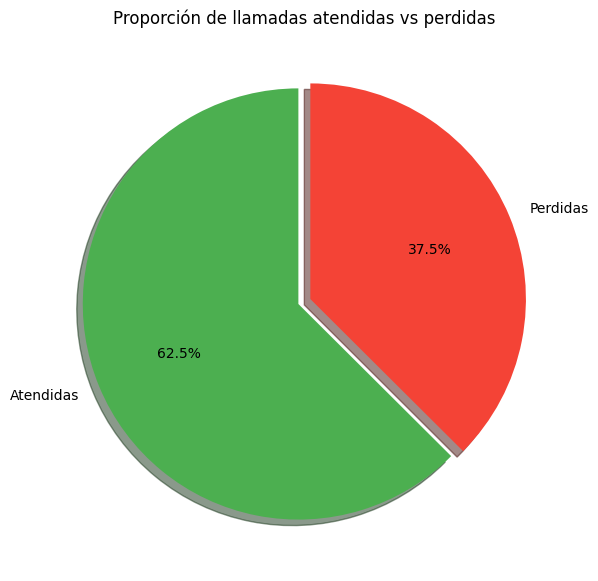

In [16]:
conteo = df_users["is_missed_call"].value_counts()

labels = ["Atendidas", "Perdidas"]
explode = (0.03, 0.03)  # pequeño efecto de separación para simular 3D

plt.figure(figsize=(7,7))
plt.pie(
    conteo,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,        # sombra = efecto 3D
    explode=explode,    # separación = volumen
    colors=["#4CAF50", "#F44336"]
)
plt.title("Proporción de llamadas atendidas vs perdidas")
plt.show()


### Conclusión

El análisis de la columna is_missed_call muestra que aproximadamente el 30% de las llamadas fueron perdidas. Este valor es consistente con la distribución de duraciones observada, donde la mediana es de 0.67 minutos (≈40 segundos), lo que indica un volumen significativo de llamadas abandonadas o colgadas antes de ser atendidas.

### 2.7 Llamadas totales por operador 

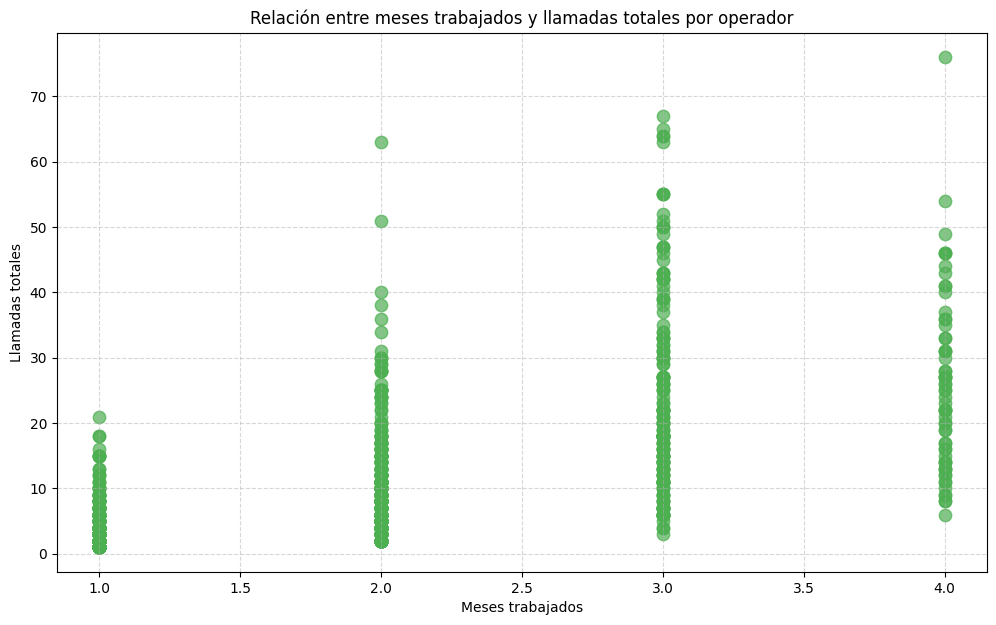

In [17]:
# Total de llamadas por operador
llamadas_totales = df_users.groupby("operator_id").size()

# Meses trabajados por operador
meses_trabajados = df_users.groupby("operator_id")["month"].nunique()

# Combinar
resumen_operadores = pd.DataFrame({
    "llamadas_totales": llamadas_totales,
    "meses_trabajados": meses_trabajados
})

# Gráfica combinada 
plt.figure(figsize=(12,7))
plt.scatter(
    resumen_operadores["meses_trabajados"],
    resumen_operadores["llamadas_totales"],
    s=80,
    alpha=0.7,
    color="#4CAF50"
)

plt.title("Relación entre meses trabajados y llamadas totales por operador")
plt.xlabel("Meses trabajados")
plt.ylabel("Llamadas totales")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Conclusión

La gráfica muestra que no hay una relación clara entre los meses trabajados y la cantidad de llamadas. Algunos operadores con varios meses activos tienen muy pocas llamadas, mientras que otros alcanzan hasta 76. También aparecen operadores con cero llamadas sin importar su antigüedad. En conjunto, esto refleja una actividad muy variable y sin una tendencia que conecte el tiempo trabajado con el volumen de llamadas.

## Conclusión Final


El dataset presenta problemas importantes de calidad: 4,900 duplicados, 8,172 valores faltantes en operator_id, más de 23,000 llamadas con duración cero y registros con tiempos que superan las 24 horas, lo que evidencia inconsistencias en la captura de información. Tras filtrar únicamente las filas con calls_count = 1, se conservaron 10,439 registros (19.37 %), permitiendo analizar solo llamadas individuales.

En este subconjunto, los operadores registran entre 40 y 76 llamadas en cuatro meses, mientras que la mayoría acumula entre 1 y 20. Este volumen es insuficiente para representar su actividad real y no permite evaluar desempeño individual. La causa principal es que el dataset original agrega múltiples llamadas en una sola fila, lo que impide conocer cuántas llamadas atendió realmente cada operador y en qué condiciones.

Debido a estas limitaciones, el análisis solo puede enfocarse en tendencias generales del sistema, como volumen mensual, proporción de llamadas atendidas vs perdidas y distribución de duraciones válidas. Para lograr un análisis confiable del desempeño de los operadores, se recomienda optimizar el proceso de recopilación de datos, evitando agregaciones y registrando cada llamada como una observación independiente.




### Vinculo Google Drive

https://drive.google.com/drive/folders/1UwPc628EBzNN2EBMJjcwkDj-PnFTOpRO?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Al tratarse de una empresa de telecomunicaciones el campo `operator_id` se refiere a cada operador humano y su desempeño en la empresa.

Recuerda que la definición de los criterios de evaluación para los evaluadores debe ser siempre argumentada en base a los datos que analizaste y debes dejar explicado en por qué se establecen esos criterios.

Haría falta también pruebas estadísticas y tu presentación final en formato PDF para exponer los resultados más relevantes de tu proyecto.

Si tienes dudas o dificultades siempre puedes utilizar los canales de co-learning. Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (3ra Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Fernando!** 

La presentación quedó super clara y muy profesional, la herramienta utilizada da una exposición creativa de los resultados obtenidos en tu análisis. 

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>